In [60]:
import pandas as pd
import numpy as np
import os 
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
years = [2021.0, 2022.0, 2023.0]
boroughs = ['manhattan', 'brooklyn', 'bronx', 'queens']

borough_year_data = {}
for y in years:
    borough_year_data[y] = {} 
    print(f"\nLoading {y} data")
    for b in boroughs:
        file_path = f"..\\Dataset\\NYC_DWT_Analysis\\{y}\\{b}.csv"
        borough_year_data[y][b] = pd.read_csv(file_path)
        print(f"Loaded {b} data")


Loading 2021.0 data
Loaded manhattan data
Loaded brooklyn data
Loaded bronx data
Loaded queens data

Loading 2022.0 data
Loaded manhattan data
Loaded brooklyn data
Loaded bronx data
Loaded queens data

Loading 2023.0 data
Loaded manhattan data
Loaded brooklyn data
Loaded bronx data
Loaded queens data


In [62]:
nta_data = {}
for y in years:
    nta_data[y] = {}
    for b in boroughs:
        df = borough_year_data[y][b].copy()

        df["has_violation"] = (df["Violation_Code"] != '0').astype(int)
        df["is_audit"] = (df["Activity_Type"] == "nyc health department audit").astype(int)

        agg = df.groupby('NTA_Code').agg(   inspection_count = ("BIN", "count"),
                                            violation_count = ("has_violation", "sum"),
                                            total_dwt = ('Number of DWT', "sum"),
                                            audit_count = ("is_audit", "sum"), ).reset_index()

        agg["violation_rate"] = agg["violation_count"]/agg["inspection_count"]
        agg["avg_dwt"]        = agg["total_dwt"]/agg["inspection_count"]
        agg["audit_fraction"] = agg["audit_count"]/agg["inspection_count"]

        nta_data[y][b] = agg.drop(columns=["violation_count", "total_dwt", "audit_count"])

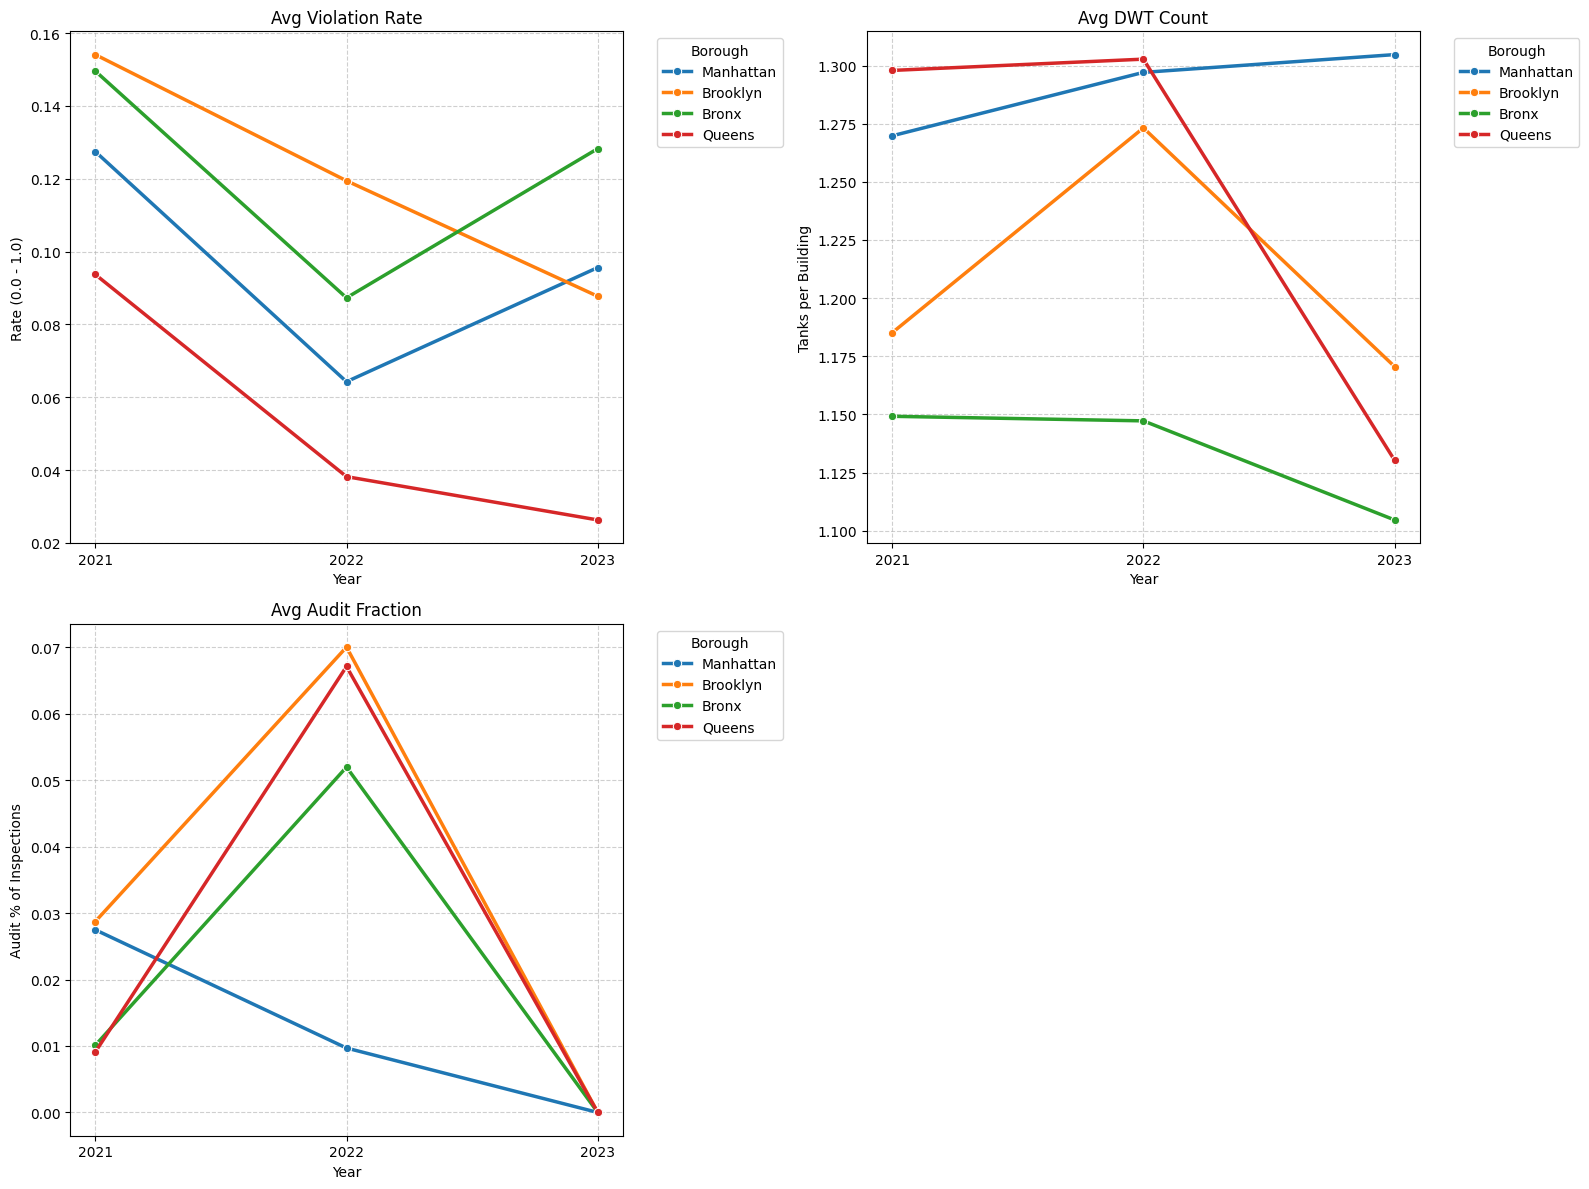

In [63]:
plot_records = []
for y in years:
    for b in boroughs:
        df_nta = nta_data[y][b]
        plot_records.append({
            "Year": int(y),
            "Borough": b.capitalize(),
            "Total Inspections": df_nta["inspection_count"].sum(),
            "Avg Violation Rate": df_nta["violation_rate"].mean(),
            "Avg DWT Count": df_nta["avg_dwt"].mean(),
            "Avg Audit Fraction": df_nta["audit_fraction"].mean()
        })

df_plot = pd.DataFrame(plot_records)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics = [
    ("Avg Violation Rate", "Rate (0.0 - 1.0)"),
    ("Avg DWT Count", "Tanks per Building"),
    ("Avg Audit Fraction", "Audit % of Inspections")
]

for i, (metric, ylabel) in enumerate(metrics):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    
    sns.lineplot(
        data=df_plot, 
        x="Year", 
        y=metric, 
        hue="Borough", 
        marker="o", 
        linewidth=2.5,
        ax=ax
    )
    
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Year")
    ax.set_xticks([2021, 2022, 2023])
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.legend(title="Borough", bbox_to_anchor=(1.05, 1), loc='upper left')

fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

Manhattan consistently has the low violation and audit rate per NTA (Neighbourhood Tabulation Area). 
This could be because it is by far the richest borough (https://www.baruch.cuny.edu/nycdata/income-taxes/per_cap.htm). ensuring its presumably consistent and good infrastructure.
In addition, it has a high number of DWTs inspected both per NTA and in general, implying that the borough is monitored regularly and admistered carefully.

On the other hand, the Bronx's low audit fraction, along with high violation rates and DWT count indicate that the borough is poorly taken care of. The same inference holds true for Queens as the second poorest borough - its low violation rate per-NTA could indicate however that its infrastructure is perhaps of better quality than the Bronx's due to its export-oriented economy.  

Coming to year-wise information, there is a noticable rise in audit fraction for all boroughs except Manhattan in 2022, only to drop below their 2021 levels the next year. This indicates that the NYC health department was taking an increased interest in the general quality of drinking water in '21 and '22, perhaps as a result of the COVID-19 pandemic.

An interesting change is the drop in the number of DWTs per Queens NTA, this could either be because of an increase in single-DWT NTAs or a decrease in inspected DWTs in general. The former would indicate an increased effort to maintain the region's infrastructure, and the latter likely represents an infrastructural issue posed by increased stressers from the pandemic environment.